In [291]:
import math
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 0. Import Datasets:

In [292]:
customers_db = pd.read_csv("data/DM_AIAI_CustomerDB.csv", sep=",", index_col=0)
flights_db = pd.read_csv("data/DM_AIAI_FlightsDB.csv", sep=",")

In [293]:
customers_db.head()

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion


In [295]:
flights_db.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,413052,2021,12,12/1/2021,2.0,2.0,9384.0,938.0,0.0,0.0
1,464105,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
2,681785,2021,12,12/1/2021,10.0,3.0,14745.0,1474.0,0.0,0.0
3,185013,2021,12,12/1/2021,16.0,4.0,26311.0,2631.0,3213.0,32.0
4,216596,2021,12,12/1/2021,9.0,0.0,19275.0,1927.0,0.0,0.0


# 1. Analysis of both table combined:

### 1.1.4. Data inconsistencies:

In [ ]:
# nr of flights != 0  distance =0 

### 1.1.5. Feature Engineering between features from each tables:

### 1.1.6. Visualizations:

#### 1.1.6.1 Univariate Analysis for newly created features:

##### 1.1.6.1.1. Metric Features:

In [326]:
def plot_histograms_side_by_side(df, cols, bins=30, figsize=(12, 4)):
    
    n = len(cols)
    if n == 0:
        return

    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0], figsize[1] * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, c in enumerate(cols):
        ax = axes[i]
        s = df[c]  
        nan_count = s.isna().sum()
        total = len(s)

        ax.hist(s, bins=bins, edgecolor="black")  
        ax.set_title(f"Histogram of {c}")
        ax.set_xlabel(c)
        ax.set_ylabel("Frequency")
        ax.grid(alpha=0.25)
        ax.text(
            0.99, 0.95,
            f"NaNs: {nan_count/total*100:.2f}%",
            transform=ax.transAxes, ha="right", va="top"
        )

    plt.tight_layout()
    plt.show()


### Graphical interpretation:

##### 1.1.6.1.2. Non-Metric Features:

In [328]:
def plot_bar_chart_top15(
    df: pd.DataFrame,
    cols: list[str],
    ncols: int = 2,
    figsize_per_row: tuple = (12, 4),
    rotate_xticks: int = 30,
):

    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_row[0], figsize_per_row[1] * nrows))
    axes = np.atleast_1d(axes).ravel()

    total_rows = len(df)

    for i, col in enumerate(cols):
        ax = axes[i]
        s = df[col].astype("string")  
        counts = s.value_counts(dropna=False)    
        counts_plot = counts.iloc[:15]          

        categories = counts_plot.index.tolist()
        values = counts_plot.values

        ax.bar(categories, values, edgecolor="black")
        ax.set_title(f"{col} (Top-15)")
        ax.set_ylabel("Count")
        ax.set_xlabel("")
        ax.grid(axis="y", alpha=0.25)
        ax.set_xticklabels(categories, rotation=rotate_xticks, ha="right")

        # Annotate percentage:
        for x, v in enumerate(values):
            pct = (v / total_rows * 100) if total_rows else 0
            ax.text(x, v, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

        # Annotate NaNs percentage:
        nan_pct = s.isna().mean() * 100
        ax.text(0.99, 0.95, f"NaNs: {nan_pct:.2f}%", transform=ax.transAxes, ha="right", va="top", fontsize=9)

    # Remove empty axis for odd number of variables:
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


### Graphical interpretation:

## Outliers of newly created features:

In [330]:
def boxplot_grid(df, cols, ncols=3, figsize=(14, 8), showfliers=True):
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(cols):
        ax = axes[i]
        s = df[col].astype(float)
        ax.boxplot(s.dropna().values, vert=True, showmeans=False, showfliers=showfliers)
        ax.set_title(f"Boxplot of {col}")
        ax.set_xticks([])                 
        ax.set_ylabel(col)
        ax.grid(axis="y", alpha=0.25)

    # Hide unused subplot:
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

### Graphical interpretation:

### Multivariate Analysis:

### Numerical x Numerical features:

In [332]:
def plot_pairwise_numeric(df, metric_features, title="Pairwise Relationship of Numerical Variables"):
    # Style and grid:
    sns.set_theme(style="ticks", rc={
        "axes.grid": True,
        "grid.color": ".9",
        "grid.linestyle": "-",
        "axes.spines.right": False,
        "axes.spines.top": False,
    })

    g = sns.pairplot(
        data=df[metric_features],
        diag_kind="hist",
        height=3.2,       
        aspect=1.0,
        corner=False,
        plot_kws=dict(
            s=14,         
            alpha=0.45,   
            linewidth=0.25,
            edgecolor="black",  
            rasterized=True     
        ),
        diag_kws=dict(
            bins=30,
            edgecolor="black",
            linewidth=0.2
        )
    )

    g.fig.suptitle(title, fontsize=18, y=1.02)
    plt.show()
    return g


### Graphical interpretation:

### Hexbin matrix:

/var/folders/p3/g5r5vfd17rb6pqnhkz47wq900000gn/T/ipykernel_23614/2124452425.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


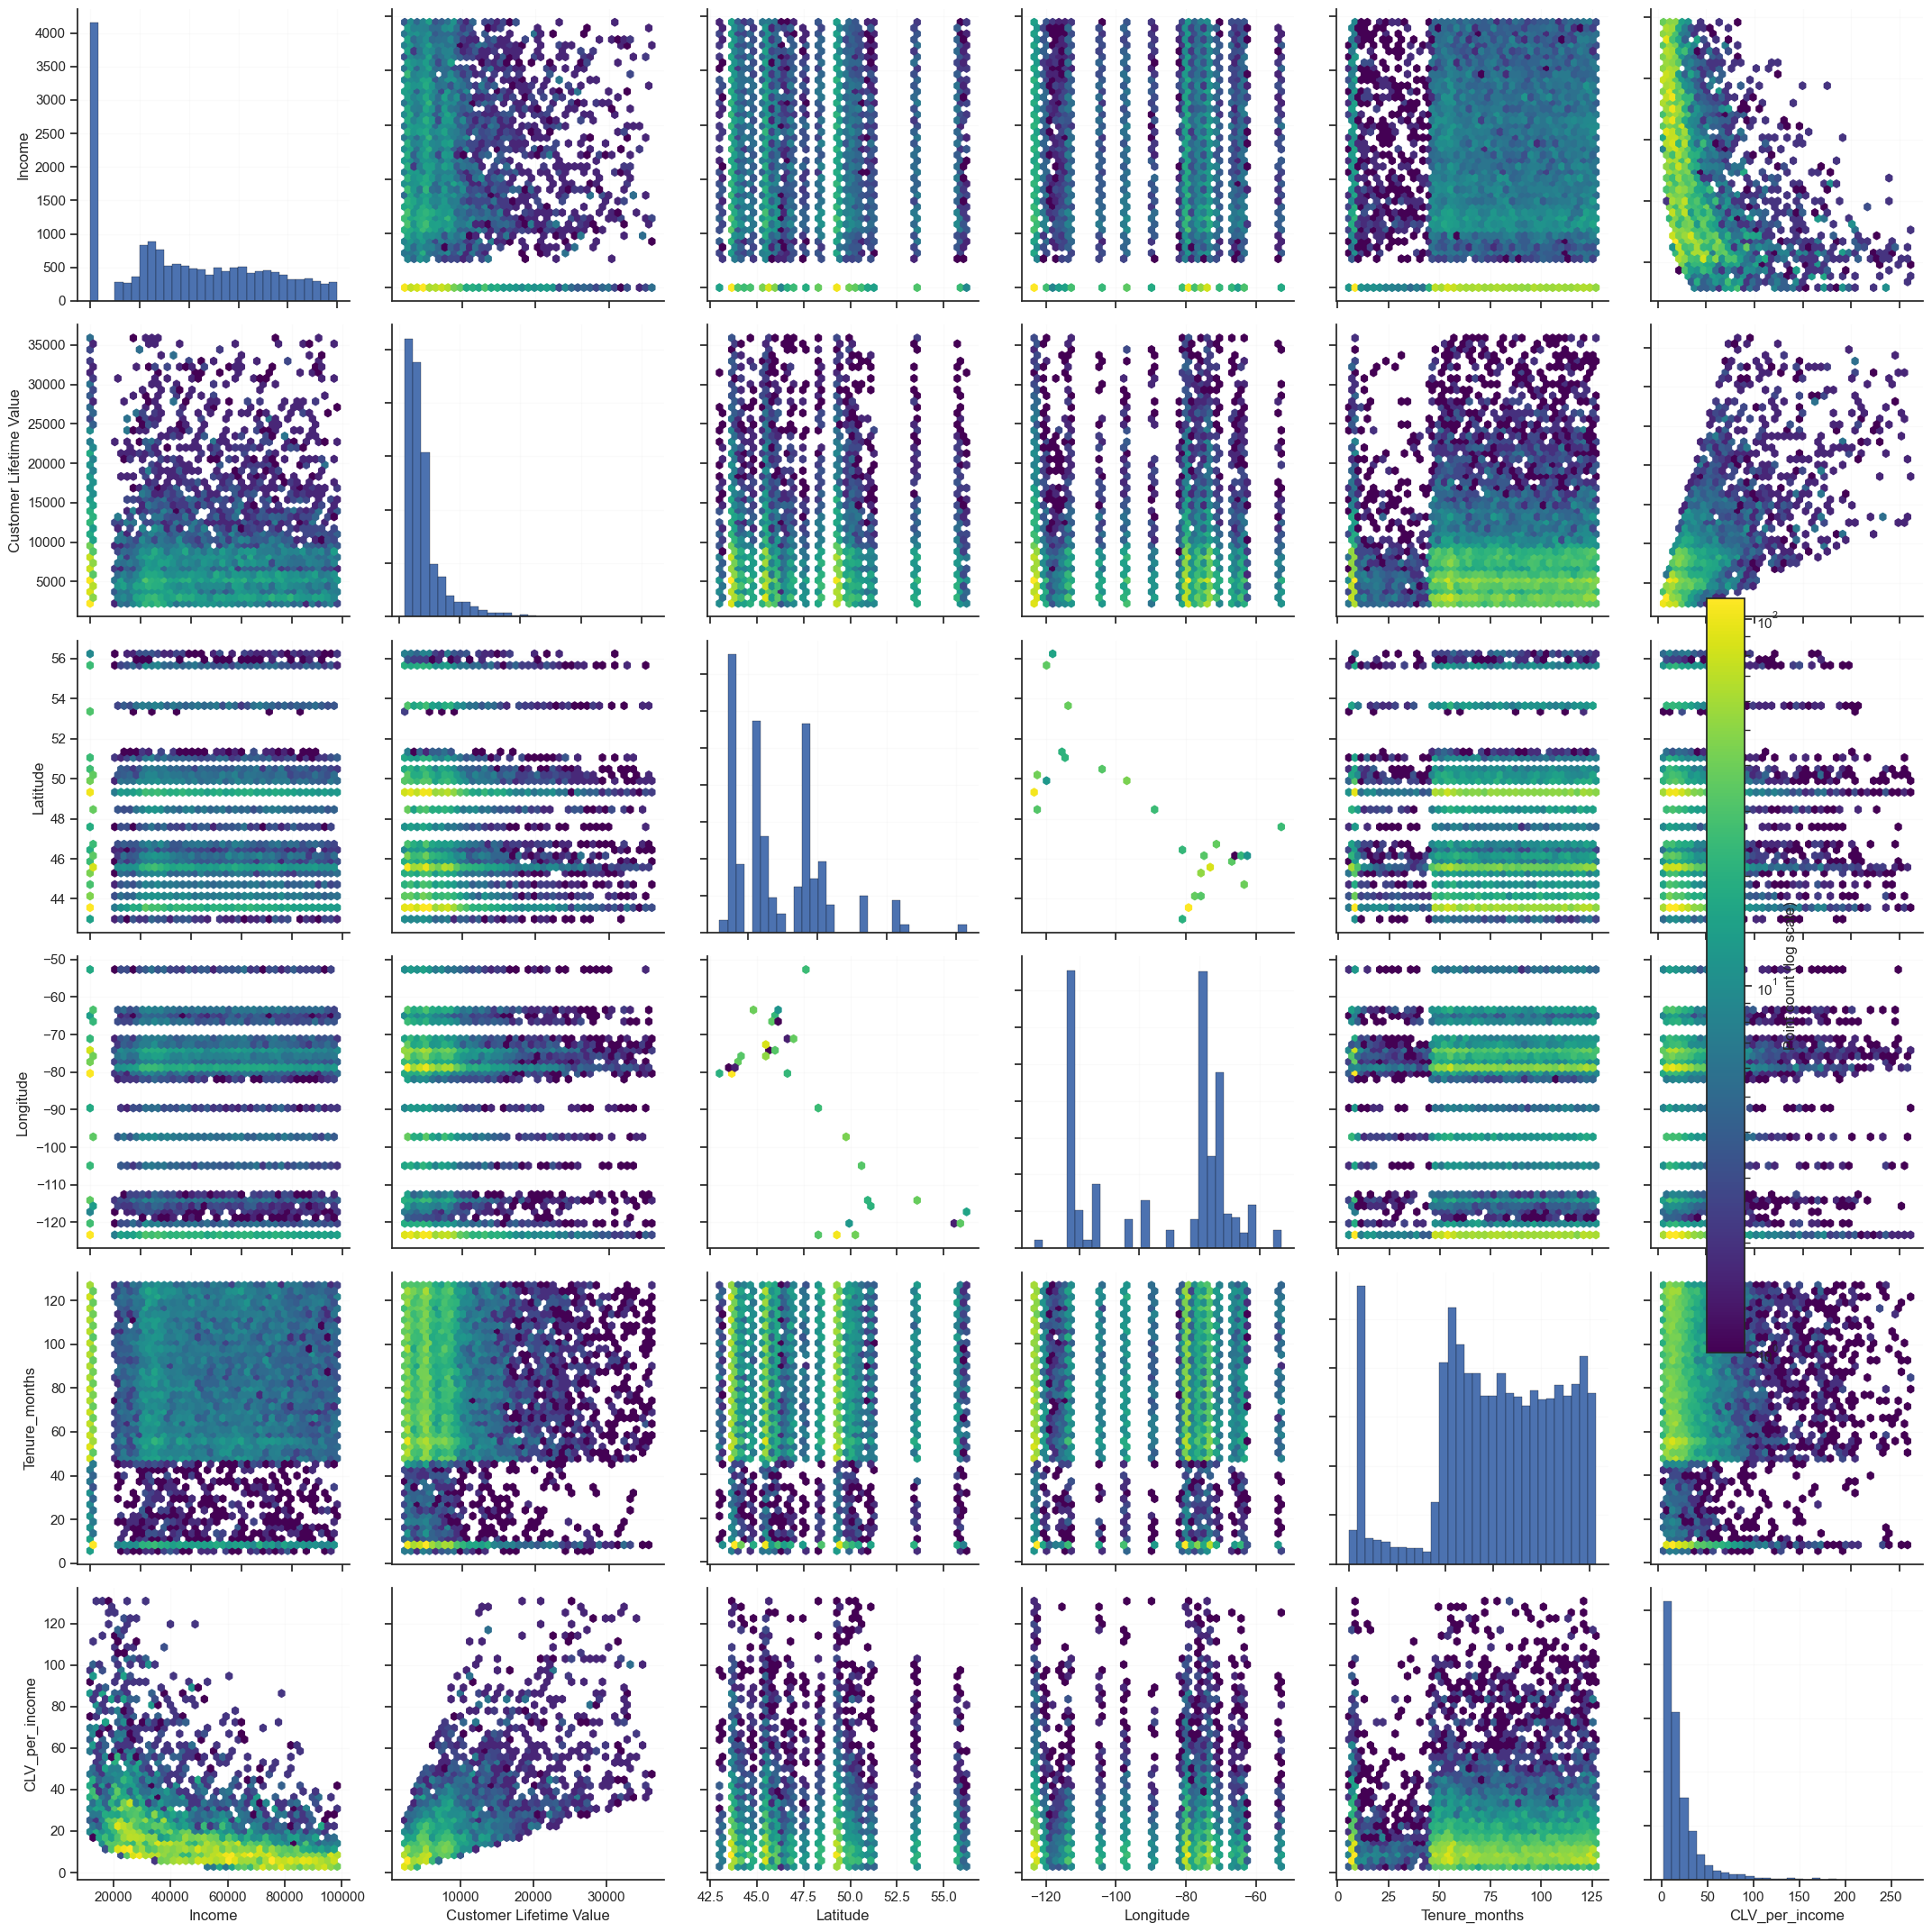

In [334]:
def hexbin_matrix(
    df: pd.DataFrame,
    cols: list[str],
    gridsize: int = 40,           # hex resolution
    clip_q: tuple[float, float] = (0.01, 0.99),  # percentile limits per axis
    log_counts: bool = True,      # log color scale for dense plots
    cmap: str = "viridis",
    mincnt: int = 1               # hide hexes with < mincnt points
):
    n = len(cols)
    fig, axes = plt.subplots(n, n, figsize=(3.6*n, 3.6*n))
    axes = np.atleast_2d(axes)

    last_hb = None  # keep a handle for a shared colorbar

    for i, ycol in enumerate(cols):
        for j, xcol in enumerate(cols):
            ax = axes[i, j]

            if i == j:
                # Diagonal: histogram of each feature
                s = df[xcol].dropna().astype(float)
                ax.hist(s, bins=30, edgecolor="black", linewidth=0.2)
                ax.set_ylabel("")
                ax.set_xlabel("")
                ax.grid(alpha=0.2)
            else:
                # Off-diagonal: hexbin for the pair
                x = df[xcol].astype(float).to_numpy()
                y = df[ycol].astype(float).to_numpy()
                mask = np.isfinite(x) & np.isfinite(y)
                x, y = x[mask], y[mask]

                # Percentile clipping for visibility
                if clip_q is not None and len(x) and len(y):
                    x1, x2 = np.quantile(x, clip_q)
                    y1, y2 = np.quantile(y, clip_q)
                    extent = [x1, x2, y1, y2]
                else:
                    extent = None

                hb = ax.hexbin(
                    x, y,
                    gridsize=gridsize,
                    mincnt=mincnt,
                    cmap=cmap,
                    bins="log" if log_counts else None,
                    extent=extent
                )
                last_hb = hb
                ax.grid(alpha=0.2)

            # Axis labels only on outer edges
            if i == n-1:
                ax.set_xlabel(cols[j])
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(cols[i])
            else:
                ax.set_yticklabels([])

    # Shared colorbar
    if last_hb is not None:
        label = "Point count (log scale)" if log_counts else "Point count"
        cbar = fig.colorbar(last_hb, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
        cbar.set_label(label)

    plt.tight_layout()
    plt.show()


hexbin_matrix(customers_db, metric_features, gridsize=40, clip_q=(0.01, 0.99), log_counts=True)


### Correlation matrix:

#### Spearman:

Handles skewness and outliers better than Pearson:

In [335]:
def plot_corr_heatmap(df, metric_features):
    
    fig = plt.figure(figsize=(10, 8)) 
    corr = df[metric_features].corr(method="spearman")
    sns.heatmap(data=corr, annot=True, )

    plt.show()

### Graphical interpretation:

### Categorical x Categorical features:

In [337]:
def plot_stacked_bars_grid(
    df,
    features,                    
    stack_by="IsCancelled",      
    ncols=2,
    top_n=12,                    
    normalize=True,             
    figsize_per_row=(12, 4),
    rotate_xticks=30
):
    # figure grid
    n = len(features)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_row[0], figsize_per_row[1]*nrows))
    axes = np.atleast_1d(axes).ravel()

    # stack order - sorted by frequency
    stack_levels = df[stack_by].astype("string").value_counts(dropna=False).index.tolist()

    for i, col in enumerate(features):
        ax = axes[i]
        s = df[col].astype("string").str.strip()

        # Keep top-N categories + 'Other'
        vc = s.value_counts(dropna=False)
        if top_n and len(vc) > top_n:
            top_vals = set(vc.head(top_n).index)
            s = s.where(s.isin(top_vals), "Other")

        # crosstab
        ct = pd.crosstab(s, df[stack_by].astype("string"), dropna=False).reindex(columns=stack_levels, fill_value=0)
        ct = ct.sort_values(ct.columns.tolist(), ascending=False)

        # normalize to percentages:
        if normalize:
            pct = ct.div(ct.sum(axis=1), axis=0).fillna(0) * 100
            plot_df = pct
            ylabel = "Percent"
        else:
            plot_df = ct
            ylabel = "Count"

        # plot stacked bars
        bottoms = np.zeros(len(plot_df))
        x = np.arange(len(plot_df.index))
        for lvl in plot_df.columns:
            vals = plot_df[lvl].values
            ax.bar(x, vals, bottom=bottoms, label=str(lvl))
            bottoms += vals

        # labels:
        ax.set_title(f"{col} × {stack_by}")
        ax.set_ylabel(ylabel)
        ax.set_xticks(x)
        ax.set_xticklabels(plot_df.index, rotation=rotate_xticks, ha="right")
        ax.grid(axis="y", alpha=0.25)

        # annotate percentages on the bars:
        if normalize:
            for xi in x:
                y0 = 0
                for lvl in plot_df.columns:
                    v = plot_df.loc[plot_df.index[xi], lvl]
                    if v >= 5:  
                        ax.text(xi, y0 + v/2, f"{v:.0f}%", ha="center", va="center", fontsize=8)
                    y0 += v

    # legend:
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title=stack_by, loc="upper center", ncol=min(len(labels), 5), frameon=False, bbox_to_anchor=(0.5, 1.02))

    # remove unused axes:
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()



### Graphical interpretation:

### Numerical x Categorical features:

In [342]:
def plot_hist_by_categories(
    df,
    numeric_col: str,
    cat_cols: list[str],
    ncols: int = 2,
    bins: int | str = 40,         
    stat: str = "density",        
    element: str = "step",         
    alpha: float = 0.35,
    figsize_per_row: tuple = (12, 4),
    title_prefix: str = "Histogram of",
):

    sns.set_theme(style="ticks")

    # Compute common bins from the numeric column (ignores NaNs)
    x = df[numeric_col].astype(float)
    bin_edges = np.histogram_bin_edges(x[np.isfinite(x)], bins=bins)

    n = len(cat_cols)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_row[0], figsize_per_row[1] * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, cat in enumerate(cat_cols):
        ax = axes[i]
        sns.histplot(
            data=df.dropna(subset=[cat]),
            x=numeric_col,
            hue=cat,
            bins=bin_edges,
            element=element,
            stat=stat,
            common_bins=True,
            alpha=alpha,
            ax=ax,
        )
        ax.set_title(f"{title_prefix} {numeric_col} by {cat}")
        ax.grid(alpha=0.25)

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()

    plt.show()


### Graphical interpretation:

## Geographical Analysis:

## Postal code with feature from customers database:

## Graphical interpretation:

## City with feature from customers database:

## Graphical interpretation:

## longitude and latitude with features customers database:

## Graphical interpretation: